# Backprop with a multi-layer-Perceptron function

## with a mathematical model of a MLP we are trying to learn back propagration

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

#this line of code will show the graphs inside of the notebook, its jp notebook specific:-
%matplotlib inline 

## Value class
- the reason we are implementing this class is basically to keep a track of what operations led us to the result 
- simply said , we are traking the previous nodes of the tree , and the tree itself is the arithmatic equation 
- we are also storing the gradient of the loss function, with respect to each node 
- the main benifit of using this data structre is that we can back propogate through the computation graph, to find out how each node influences the loss function 
### Nuances of the Value class 
- using += is really important cuase of the accumulation property of the chain rule, this only shows up when onve var is used multiple times 
- when adding/multiplying an integer/float we are simply checking if the var is an instance of Value, if its not then we wrap the var in a Value obj
- __rmul__ would check if the objs could be mutiplied in the other direction , ex:- 2*a = a*2
- the exp function is pretty simply as local derivative of the e^x =e^x
- here instead of conventional division we are using = a * (b^(-1)) = (a*(1/b)) = a/b
- here since the __truediv__ method uses a power we would be treating the power as a node in the computational graph 
- the __pow__ method is only supporting int/float powers for now, if raises and error in the power is not a int/float
- once the power is set to a int/float , we only need to find the local var and chain it , and here the local var is x^n = n*x^(n-1)

In [22]:
class Value:
    
    def __init__(self, data, _children=(), _op='' , label=''):
         self.data = data
         self.prev = set(_children)
         self.op = _op
         self.label = label
         self.grad = 0  
         self._backward = lambda: None #this is a lambda function, in this case the function does nothing
         
    def __repr__(self):
         return f"Value(data={self.data})"
    
    def __add__(self, other):    
          if isinstance(other, Value) == False: #this check is important in case we need to add an integer
             other = Value(other) 
          out = Value(self.data + other.data, (self,other), '+')   
          def _backward():
               self.grad += 1 * out.grad 
               other.grad += 1 * out.grad   
          out._backward = _backward     
          return out 
     
    def __sub__(self, other): # this would although use the upper add function, we get the thing done by doing = self - other
        return self + (-other)

    def __neg__(self):
         return self * -1   #this will be using multiplication function, but we still get it done by negating the number (-self)

    def __mul__(self, other):
          if isinstance(other, Value) == False:
             other = Value(other)  
          out = Value(self.data * other.data, (self,other), '*') 
          def _backward():
               self.grad += other.data * out.grad
               other.grad += self.data * out.grad
          out._backward = _backward          
          return out
     
    def __rmul__(self, other):
          return self * other
     
    def __pow__(self, other):
          assert isinstance(other , (int, float)) , 'only supporting int/float powers for now'   #this is a gaurd clause in python works if not condition then raise a AssertionError
          out = Value(self.data**other, (self, ), f'**{other}')
          
          def _backward():
               self.grad += other * (self.data**(other - 1)) * out.grad
          out._backward = _backward
          return out
               
    def __truediv__(self, other): #self/other = self * other**-1
         return self * other**-1
      
    def exp(self):
         x = self.data
         out = Value(math.exp(x), (self, ), 'exp') 
         
         def _backward():
              self.grad += out.data * out.grad
         out._backward = _backward
         return out      
     
    def tanh(self):
         x=self.data
         t=(math.exp(2*x) -1)/(math.exp(2*x)+1)
         output = Value(t, (self, ), 'tanh')
         def _backward():     
               self.grad += (1-t**2)*output.grad
         output._backward = _backward    
         return output
    
    def backward(self):
     topo = []
     visited = set()
     def build_topo(v):
          if v not in visited:
               visited.add(v)
               for child in v.prev:
                    build_topo(child)
               topo.append(v)
     build_topo(self)    
     
     self.grad = 1
     for node in reversed(topo):
          node._backward()

## Code to draw the computional graph
- We are doing a DFS graph traversal to draw each node

In [23]:
from graphviz import Digraph

def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # value node (rounded box)
        dot.node(uid, label=f"{{ {n.label} | data: {n.data:.4f} | grad: {n.grad:.4f} }}", shape='record')
        # if this value was produced by an op, create an op node
        if n.op:
            op_uid = uid + n.op
            dot.node(op_uid, label=n.op)
            dot.edge(op_uid, uid)

    for n1, n2 in edges:
        # connect n1 to n2's op node
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot

## MLP code

### class neuron
- first we initialise some random values for w and b 
- fairly simple and compact implementation of the activation function, we are taiking a zip and interating through it
- and then as usual we are passing this activation function through a non linear function

### class layer
- first we create a list of neurons, this list is of size = nout, and each neuron is constructed to expect  nin inputs(so each neuron gets its own nin random weights + 1 random bias)
- whats happening here is basically, we pass the same input x to each new instance of a neuron
- and each neuron in this list(self.neurons) has unique charachteristics, as a new instance is being created every time with random weights and biases
- so basically we are passing the same input vector x = (n(x)) to each unique neuron, producing nout number of unique outputs

### class MLP 
- so MLP is basically where we stack each layer, and calculate the forward pass sequentially
- in this class we take nin and nouts as parameters, nin is the single int which is the size of the input vector , and nouts in the output size of each layer
- first we build a boundry size, here basically The output size of one layer = the input size of the next layer
- we build this list cause to create each layer we need to 2 numbers Layer(nin, nout), how many inputs it takes and how many neurons it has in each Layer, and these numbers are next to each other in this list
- len(nouts) is the number of layers, lets say for eg its 3, so the loop would go through 3 iterations
- in each iteration it creates a new instance of the layer class with layer(nin, nout) nin=sz(i), nout=sz(i+1)
- once we have a list of layer object, thing get beautifully simple, as we can simply call each layer with input vector x
#### Dry Run of the MLP class
```
nin  = 3
nout = [4, 4, 1]              # 3 layers wanted
sz   = [3] + [4, 4, 1]        # = [3, 4, 4, 1]
len(nout) = 3                 # so loop i over 0, 1, 2

i = 0:  Layer(sz[0], sz[1])  →  Layer(3, 4)   # input layer: 3→4
i = 1:  Layer(sz[1], sz[2])  →  Layer(4, 4)   # hidden:      4→4
i = 2:  Layer(sz[2], sz[3])  →  Layer(4, 1)   # output:      4→1
```

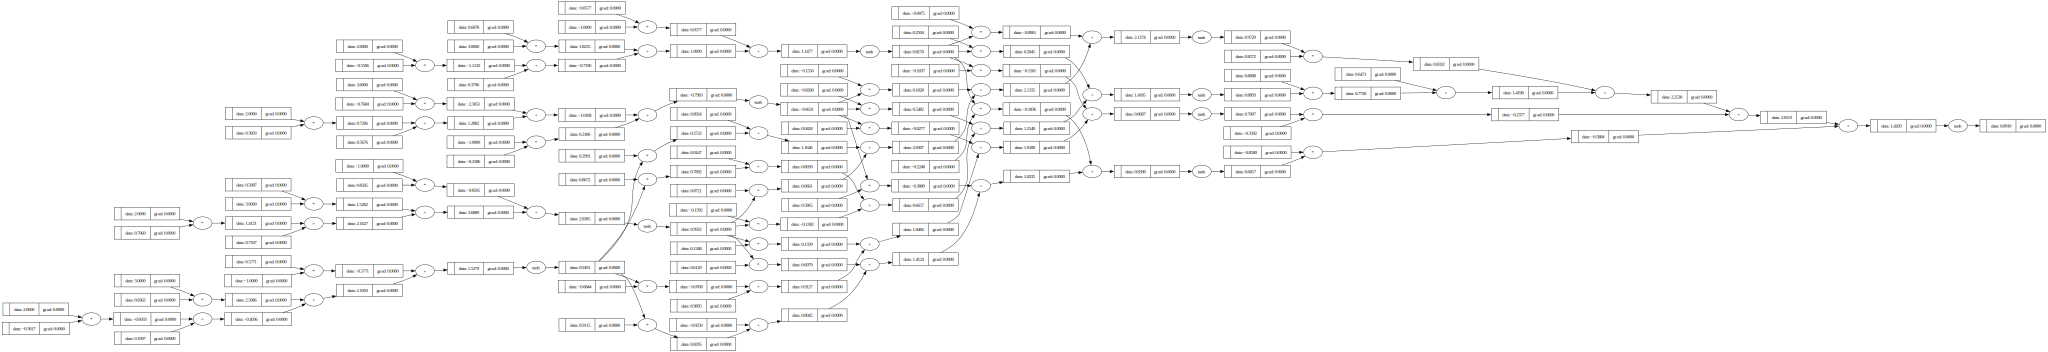

In [ ]:
class Neuron: 
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for x in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        # (x*w)+b
        activation = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        output = activation.tanh() # put the activation func through a non-linear function'
        return output
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outputs = [ n(x) for n in self.neurons] #call each neuron in the list self.neurons with the input vector X
        return outputs[0] if len(outputs) == 1 else outputs      
    
class MLP:
    def __init__(self, nin , nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x 
                
x = [2.0, 3.0, -1.0]
mlp = MLP(3, [4, 4, 1])
mlp(x)       
draw_dot(mlp(x))
            